Loading IMDB dataset...


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Starting Training for 10 Full Epochs...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 93ms/step - accuracy: 0.5059 - loss: 0.6970 - val_accuracy: 0.4942 - val_loss: 0.6966
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.5232 - loss: 0.6930 - val_accuracy: 0.4962 - val_loss: 0.6948
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 92ms/step - accuracy: 0.5501 - loss: 0.6792 - val_accuracy: 0.5088 - val_loss: 0.7030
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.6269 - loss: 0.5999 - val_accuracy: 0.4964 - val_loss: 0.7690
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 92ms/step - accuracy: 0.7014 - loss: 0.4603 - val_accuracy: 0.5254 - val_loss: 0.9283
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.7226 - loss: 0.4090 - val_accuracy: 0.5084 - val_loss: 1.1297
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.7343 - loss: 0.3939 - val_accuracy: 0.5126 - val_loss: 1.2822
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/

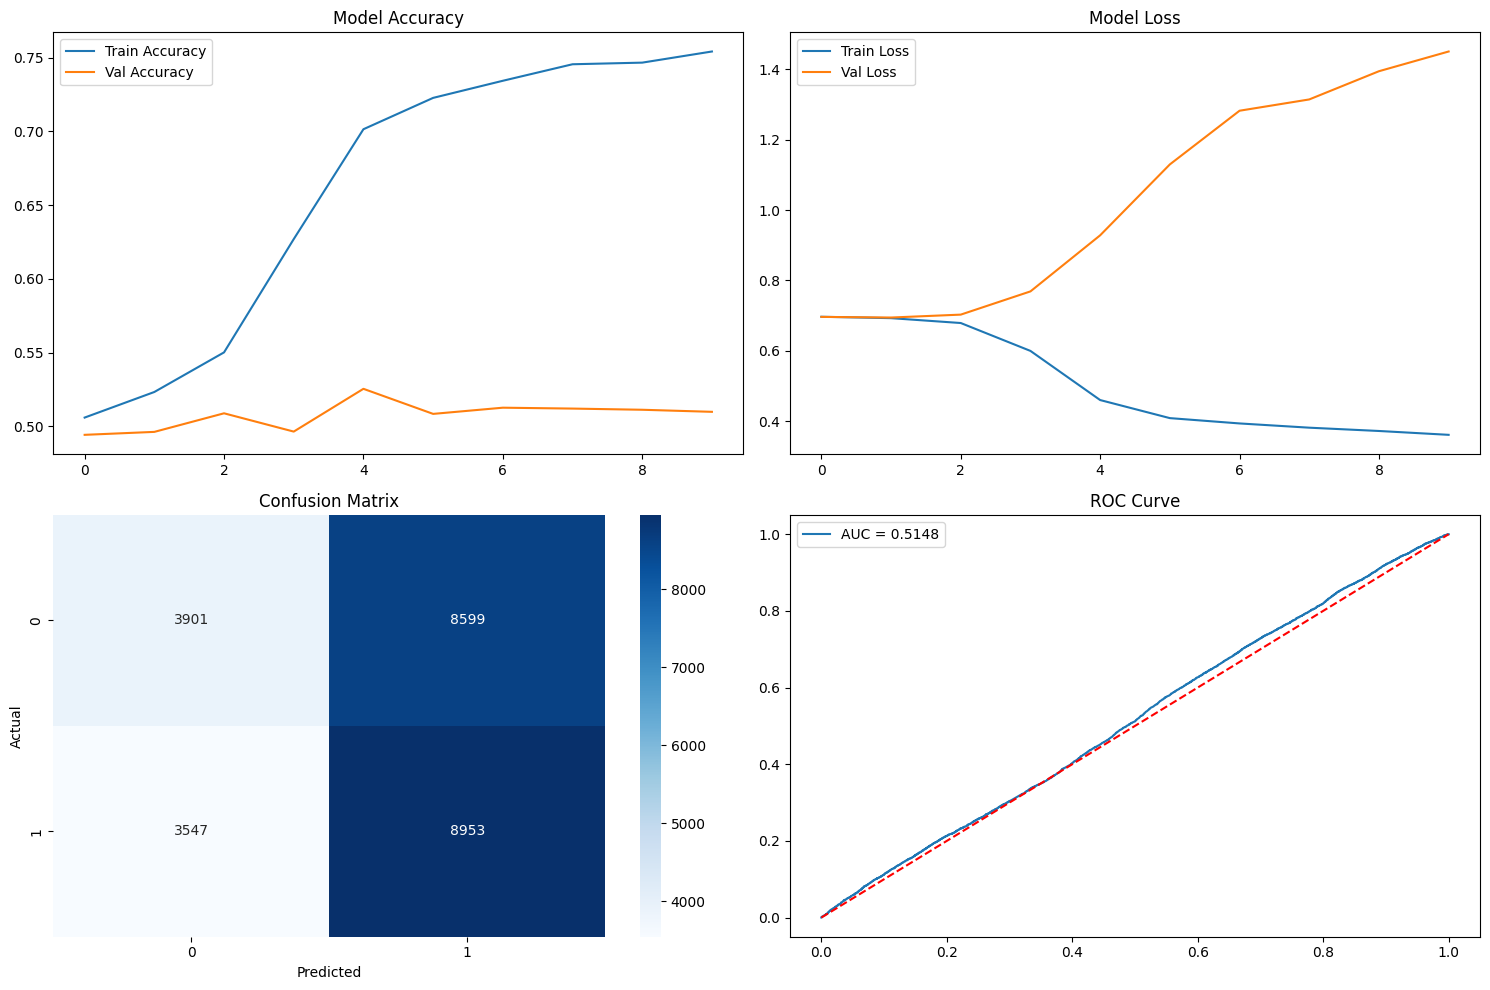


REVIEW TEXT SAMPLE                                                          | ACTUAL       | PREDICTED   
--------------------------------------------------------------------------------------------------------------
please give this one a miss br br   and the rest of the cast rendered te... | 0 (Neg)      | 1 (Pos)     
this film requires a lot of patience because it focuses on mood and char... | 1 (Pos)      | 1 (Pos)     
many animation buffs consider   the great forgotten genius of one specia... | 1 (Pos)      | 1 (Pos)     
i generally love this type of movie however this time i found myself wan... | 0 (Neg)      | 1 (Pos)     
like some other people wrote i'm a die hard mario fan and i loved this g... | 1 (Pos)      | 1 (Pos)     
i'm absolutely disgusted this movie isn't being sold all who love this m... | 1 (Pos)      | 1 (Pos)     
originally supposed to be just a part of a huge epic the year  depicting... | 1 (Pos)      | 1 (Pos)     
the  richard  dog is  to  joan fontaine 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout

# ==========================================
# 1. LOAD AND DECODE DATASET
# ==========================================
vocab_size = 10000
max_length = 200

print("Loading IMDB dataset...")
(X_train_seq, y_train), (X_test_seq, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

word_index = tf.keras.datasets.imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

def decode_review(text_seq):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in text_seq])

# ==========================================
# 2. PREPROCESSING (PADDING)
# ==========================================
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# ==========================================
# 3. BUILD RNN ARCHITECTURE
# ==========================================
model = Sequential([
    Embedding(vocab_size, 128),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ==========================================
# 4. TRAINING (FOR FULL 10 EPOCHS)
# ==========================================
print("\nStarting Training for 10 Full Epochs...")
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64
)

# ==========================================
# 5. EVALUATION & PREDICTIONS
# ==========================================
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)

# ==========================================
# 6. VISUALIZATION
# ==========================================
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Model Accuracy"); plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss"); plt.legend()

plt.subplot(2, 2, 3)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual")

plt.subplot(2, 2, 4)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.4f}")
plt.plot([0,1], [0,1], 'r--')
plt.title("ROC Curve"); plt.legend()

plt.tight_layout()
plt.show()

# ==========================================
# 7. OUTPUT TABLE: MAPPED SENTIMENT
# ==========================================
print("\n" + "="*110)
print(f"{'REVIEW TEXT SAMPLE':<75} | {'ACTUAL':<12} | {'PREDICTED':<12}")
print("-" * 110)

for i in range(10):
    raw_text = decode_review(X_test_seq[i])
    clean_text = raw_text.replace('?', '').strip()[:72] + "..."

    actual_val = y_test[i]
    pred_val = y_pred[i][0]

    # Mapping: 1 (Pos), 0 (Neg)
    actual_str = f"{actual_val} (Pos)" if actual_val == 1 else f"{actual_val} (Neg)"
    pred_str = f"{pred_val} (Pos)" if pred_val == 1 else f"{pred_val} (Neg)"

    print(f"{clean_text:<75} | {actual_str:<12} | {pred_str:<12}")

print("="*110)

# ==========================================
# 8. FINAL METRICS SUMMARY
# ==========================================
print("\nFINAL EVALUATION METRICS")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Precision:     {precision_score(y_test, y_pred):.4f}")
print(f"Recall:        {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:      {f1_score(y_test, y_pred):.4f}")
print(f"AUC:           {auc(fpr, tpr):.4f}")